# German Equity Market Analysis: DAX vs. MDAX in H1 2026

### Index- and Company-Level Performance, Risk, and Market Breadth in the German Equity Market

This project compares the DAX (large-cap) and MDAX (mid-cap) indices over the first half of 2026, at both the index level and the individual constituent level. The goal is to determine which index performed better, which was riskier, and whether the market move was broad-based or concentrated in a few large companies.

Python is used for data collection, cleaning, and metric calculation. The cleaned tables are exported for Power BI, where the visualization and interactive analysis take place.

| Area | Scope |
|---|---|
| Universe | DAX (40) and MDAX (50) constituents, Xetra-listed, plus the two indices themselves |
| Period | 2025-12-30 to 2026-06-30 (H1 2026, with a prior year-end reference point) |
| Data source | Yahoo Finance (`yfinance`) for prices; Deutsche Börse / STOXX for index composition |
| Output | Four cleaned tables for Power BI: daily market data, company metadata, company summary, monthly summary |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path


## 2. Define Time Period and File Paths

The analysis window is the first half of 2026. 30 December 2025 is included as the prior year-end reference point, needed to compute returns from the start of the year.

In [2]:
START_DATE = "2025-12-30"  # last trading day of Dec 2025, used as the YTD reference point
END_DATE = "2026-06-30"    # last trading day of Jun 2026

# Downloaded a week before START_DATE so the forward-fill in Section 5 has a real prior
# value to draw on even for the very first row of the analysis window. Trimmed back to
# START_DATE after cleaning.
DOWNLOAD_START = (pd.Timestamp(START_DATE) - pd.Timedelta(days=7)).strftime("%Y-%m-%d")

RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

INDEX_TICKERS = {"^GDAXI": "DAX", "^MDAXI": "MDAX"}


## 3. Load Index Constituents

The company universe is loaded from two CSV files in `data/raw/`: `dax_constituents.csv` and `mdax_constituents.csv` (columns: `ticker`, `name`, `sector`, `index_group`, `as_of_date`).

Researched starting lists reflect the official Deutsche Börse composition for the 30 June 2026 cutoff, written below the first time this notebook runs so it is reproducible end to end without any manual step.

One index change during H1 2026 is already accounted for: **Hochtief (`HOT.DE`)** joined the DAX and **Porsche SE (`PAH3.DE`)** moved down to the MDAX, effective 22 June 2026 (confirmed via multiple financial-news sources, e.g. Table.Briefings and Der Aktionär). Both lists below reflect this — Porsche SE is listed under MDAX, not DAX.

One open point remains: five MDAX rows are 2025 stock-exchange newcomers (`TKMS.DE`, `AMV0.DE`, `R3NK.DE`, `IOS.DE`, `SMHN.DE`) — their `yfinance` tickers are lower-confidence than the rest of the list, though all returned valid data in testing.

If a ticker below turns out to be wrong, the data-quality check in Section 4 will flag it under "Tickers with no data at all" — fix it there rather than searching blind.

In [3]:
DAX_STARTER = [
    ("ADS.DE", "Adidas", "Apparel"),
    ("AIR.PA", "Airbus", "Aerospace & Defence"),
    ("ALV.DE", "Allianz", "Financial Services"),
    ("BAS.DE", "BASF", "Chemicals"),
    ("BAYN.DE", "Bayer", "Pharmaceuticals"),
    ("BEI.DE", "Beiersdorf", "Consumer Goods"),
    ("BMW.DE", "BMW", "Automotive"),
    ("BNR.DE", "Brenntag", "Distribution"),
    ("CBK.DE", "Commerzbank", "Financial Services"),
    ("CON.DE", "Continental", "Automotive"),
    ("DTG.DE", "Daimler Truck", "Automotive"),
    ("DBK.DE", "Deutsche Bank", "Financial Services"),
    ("DB1.DE", "Deutsche Boerse", "Financial Services"),
    ("DHL.DE", "Deutsche Post", "Logistics"),
    ("DTE.DE", "Deutsche Telekom", "Telecommunication"),
    ("EOAN.DE", "E.ON", "Utilities"),
    ("FRE.DE", "Fresenius", "Healthcare"),
    ("FME.DE", "Fresenius Medical Care", "Healthcare"),
    ("G1A.DE", "GEA Group", "Mechanical Engineering"),
    ("HNR1.DE", "Hannover Re", "Insurance"),
    ("HEI.DE", "Heidelberg Materials", "Construction Materials"),
    ("HEN3.DE", "Henkel", "Consumer Goods"),
    ("IFX.DE", "Infineon Technologies", "Technology"),
    ("MBG.DE", "Mercedes-Benz Group", "Automotive"),
    ("MRK.DE", "Merck", "Pharmaceuticals"),
    ("MTX.DE", "MTU Aero Engines", "Aerospace & Defence"),
    ("MUV2.DE", "Munich Re", "Financial Services"),
    ("HOT.DE", "Hochtief", "Construction"),
    ("QIA.DE", "Qiagen", "Biotech"),
    ("RHM.DE", "Rheinmetall", "Aerospace & Defence"),
    ("RWE.DE", "RWE", "Utilities"),
    ("SAP.DE", "SAP", "Technology"),
    ("G24.DE", "Scout24", "E-Commerce"),
    ("SIE.DE", "Siemens", "Industrials"),
    ("ENR.DE", "Siemens Energy", "Energy Technology"),
    ("SHL.DE", "Siemens Healthineers", "Medical Equipment"),
    ("SY1.DE", "Symrise", "Chemicals"),
    ("VOW3.DE", "Volkswagen Group", "Automotive"),
    ("VNA.DE", "Vonovia", "Real Estate"),
    ("ZAL.DE", "Zalando", "E-Commerce"),
]

dax_path = RAW_DIR / "dax_constituents.csv"
starter = pd.DataFrame(DAX_STARTER, columns=["ticker", "name", "sector"])
starter["index_group"] = "DAX"
starter["as_of_date"] = "2026-06-30"
starter.to_csv(dax_path, index=False)

MDAX_STARTER = [
    ("P911.DE", "Porsche AG", "Automotive"),
    ("PAH3.DE", "Porsche SE", "Automotive"),
    ("TLX.DE", "Talanx", "Financial Services"),
    ("8TRA.DE", "Traton", "Automotive"),
    ("KBX.DE", "Knorr-Bremse", "Industrials"),
    ("SRT3.DE", "Sartorius", "Biotech"),
    ("DWS.DE", "DWS Group", "Financial Services"),
    ("DHER.DE", "Delivery Hero", "E-Commerce"),
    ("TKA.DE", "Thyssenkrupp", "Industrials"),
    ("NDX1.DE", "Nordex", "Renewable Energy"),
    ("LHA.DE", "Lufthansa", "Airlines"),
    ("HAG.DE", "Hensoldt", "Defence"),
    ("EVK.DE", "Evonik Industries", "Chemicals"),
    ("HLE.DE", "Hella", "Automotive"),
    ("NDA.DE", "Aurubis", "Metals"),
    ("NEM.DE", "Nemetschek", "Software"),
    ("RAA.DE", "Rational", "Manufacturing"),
    ("SHA0.DE", "Schaeffler", "Automotive"),
    ("FRA.DE", "Fraport", "Airport Operator"),
    ("KGX.DE", "KION Group", "Industrials"),
    ("EVD.DE", "CTS Eventim", "Leisure & Events"),
    ("TKMS.DE", "TKMS", "Defence"),  # low-confidence: 2025 spin-off, verify ticker
    ("FPE3.DE", "Fuchs", "Chemicals"),
    ("RRTL.DE", "RTL Group", "Media"),
    ("UTDI.DE", "United Internet", "Telecommunication"),
    ("IOS.DE", "IONOS Group", "IT Services"),  # low-confidence: recent listing, verify ticker
    ("BC8.DE", "Bechtle", "IT Services"),
    ("WCH.DE", "Wacker Chemie", "Chemicals"),
    ("AG1.DE", "Auto1 Group", "E-Commerce"),
    ("R3NK.DE", "Renk Group", "Defence"),  # low-confidence: 2024 IPO, verify ticker
    ("AIXA.DE", "Aixtron", "Semiconductor Equipment"),
    ("AMV0.DE", "Aumovio", "Automotive Technology"),  # low-confidence: 2025 spin-off, verify ticker
    ("KRN.DE", "Krones", "Manufacturing"),
    ("LEG.DE", "LEG Immobilien", "Real Estate"),
    ("TUI1.DE", "TUI", "Tourism"),
    ("FTK.DE", "flatexDEGIRO", "Financial Services"),
    ("PUM.DE", "Puma", "Apparel"),
    ("SZG.DE", "Salzgitter", "Steel"),
    ("SDF.DE", "K+S", "Mining"),
    ("FNTN.DE", "Freenet", "Telecommunication"),
    ("GBF.DE", "Bilfinger", "Industrial Services"),
    ("BOSS.DE", "Hugo Boss", "Apparel"),
    ("ELG.DE", "Elmos Semiconductor", "Semiconductors"),
    ("TEG.DE", "TAG Immobilien", "Real Estate"),
    ("JEN.DE", "Jenoptik", "Technology"),
    ("WAF.DE", "Siltronic", "Semiconductors"),
    ("AT1.DE", "Aroundtown", "Real Estate"),
    ("DEZ.DE", "Deutz", "Manufacturing"),
    ("SMHN.DE", "Suess MicroTec", "Semiconductor Equipment"),  # low-confidence: verify ticker
    ("LXS.DE", "Lanxess", "Chemicals"),
]
# 50 rows, including Porsche SE (PAH3.DE), which moved from DAX to MDAX on 22.06.2026.

mdax_path = RAW_DIR / "mdax_constituents.csv"
starter = pd.DataFrame(MDAX_STARTER, columns=["ticker", "name", "sector"])
starter["index_group"] = "MDAX"
starter["as_of_date"] = "2026-06-30"
starter.to_csv(mdax_path, index=False)

dax_constituents = pd.read_csv(dax_path)
mdax_constituents = pd.read_csv(mdax_path)
company_metadata = pd.concat([dax_constituents, mdax_constituents], ignore_index=True)

print("DAX constituents:", len(dax_constituents), "| MDAX constituents:", len(mdax_constituents))
company_metadata.head()


DAX constituents: 40 | MDAX constituents: 50


,ticker,name,sector,index_group,as_of_date
0,ADS.DE,Adidas,Apparel,DAX,2026-06-30
1,AIR.PA,Airbus,Aerospace & Defence,DAX,2026-06-30
2,ALV.DE,Allianz,Financial Services,DAX,2026-06-30
3,BAS.DE,BASF,Chemicals,DAX,2026-06-30
4,BAYN.DE,Bayer,Pharmaceuticals,DAX,2026-06-30


## 4. Download Historical Price Data

Daily prices are downloaded for the two indices and every constituent, starting a week before `START_DATE` (see Section 2) so gaps at the very start of the analysis window can still be forward-filled from real history.

In [4]:
all_tickers = list(INDEX_TICKERS.keys()) + company_metadata["ticker"].tolist()

raw_prices = yf.download(
    all_tickers,
    start=DOWNLOAD_START,
    end=END_DATE,
    auto_adjust=False,
    group_by="ticker",
    progress=False,
)

raw_prices.to_pickle(RAW_DIR / "raw_prices.pkl")  # keep the raw download before any cleaning
raw_prices.shape


(129, 552)

Data quality check: confirms the date range, flags tickers with no data at all, and shows both which tickers and which dates carry the most missing daily closes (missing-by-date shows whether gaps cluster on one date, e.g. a non-Xetra listing's own holiday, or are scattered).

In [5]:
downloaded_tickers = raw_prices.columns.get_level_values(0).unique()
missing_tickers = sorted(set(all_tickers) - set(downloaded_tickers))

print("Date range:", raw_prices.index.min(), "to", raw_prices.index.max())
print("Trading days downloaded:", len(raw_prices))
print("Tickers requested:", len(all_tickers))
print("Tickers with no data at all:", missing_tickers if missing_tickers else "none")

adj_close_na = raw_prices.loc[:, (slice(None), "Adj Close")].isna()

missing_per_ticker = adj_close_na.sum().droplevel(1).sort_values(ascending=False)
print("\nMissing daily closes, top 10 tickers:")
display(missing_per_ticker.head(10))

missing_per_date = adj_close_na.sum(axis=1).sort_values(ascending=False)
print("\nMissing daily closes, top 5 dates:")
display(missing_per_date.head(5))


Date range: 2025-12-23 00:00:00 to 2026-06-29 00:00:00
Trading days downloaded: 129
Tickers requested: 92
Tickers with no data at all: none

Missing daily closes, top 10 tickers:


Ticker
P911.DE    2
DEZ.DE     2
BAS.DE     2
MRK.DE     2
WCH.DE     2
SHL.DE     2
DWS.DE     2
ADS.DE     2
^MDAXI     2
WAF.DE     2
dtype: int64


Missing daily closes, top 5 dates:


Date
2025-12-24    91
2025-12-31    91
2025-12-23     0
2025-12-29     0
2025-12-30     0
dtype: int64

## 5. Clean and Align Trading Data

The wide multi-ticker frame is reshaped into a long table (one row per ticker per day). Gaps of up to two trading days are forward-filled per ticker using the buffer week downloaded before `START_DATE`; anything still missing after that is dropped rather than filled, and the exact count is printed below for the README. A forward-filled price means no new trade happened, so `volume` for that day is set to 0 rather than forward-filled. The frame is then trimmed back to the official `START_DATE`–`END_DATE` window.

In [6]:
def to_long_format(raw, tickers):
    frames = []
    for ticker in tickers:
        if ticker not in raw.columns.get_level_values(0):
            continue
        sub = raw[ticker][["Adj Close", "Volume"]].copy()
        sub.columns = ["adj_close", "volume"]
        sub["ticker"] = ticker
        frames.append(sub)
    return pd.concat(frames).reset_index().rename(columns={"Date": "date"})


prices_long = to_long_format(raw_prices, all_tickers)
prices_long = prices_long.drop_duplicates(["date", "ticker"]).sort_values(["ticker", "date"])
n_missing_before_fill = int(prices_long["adj_close"].isna().sum())

# Forward-fill gaps of up to 2 trading days per ticker. DOWNLOAD_START (Section 2) is a
# week before START_DATE specifically so this has real history to draw on even for the
# first row of the official analysis window.
prices_long["adj_close"] = prices_long.groupby("ticker")["adj_close"].ffill(limit=2)
n_missing_after_fill = int(prices_long["adj_close"].isna().sum())
prices_long = prices_long.dropna(subset=["adj_close"])

# A forward-filled adj_close means no new trade happened that day (e.g. a half trading
# day like 24 or 31 Dec) -- volume for that day is genuinely 0, not missing, so it is
# not forward-filled the same way.
prices_long["volume"] = prices_long["volume"].fillna(0)

# Trim the extra buffer week off now that it has done its job
prices_long = prices_long[prices_long["date"] >= START_DATE].reset_index(drop=True)

print(f"Missing adj_close before forward-fill: {n_missing_before_fill}")
print(f"Still missing after forward-fill (limit=2) -- these rows are dropped: {n_missing_after_fill}")
print(f"Rows in the final analysis window ({START_DATE} to {END_DATE}): {len(prices_long)}")
prices_long.head()


Missing adj_close before forward-fill: 182
Still missing after forward-fill (limit=2) -- these rows are dropped: 0
Rows in the final analysis window (2025-12-30 to 2026-06-30): 11592


,date,adj_close,volume,ticker
0,2025-12-30,30.500000,104661.0,8TRA.DE
1,2025-12-31,30.500000,0.0,8TRA.DE
2,2026-01-02,31.379999,127006.0,8TRA.DE
3,2026-01-05,30.840000,95029.0,8TRA.DE
4,2026-01-06,31.780001,134401.0,8TRA.DE


## 6. Calculate Daily and Cumulative Returns

Daily returns are the day-over-day percentage change in the adjusted close. Cumulative returns compound the daily returns from the start of the period.

In [7]:
prices_long = prices_long.sort_values(["ticker", "date"])
prices_long["daily_return"] = prices_long.groupby("ticker")["adj_close"].pct_change()
prices_long["cum_return"] = (
    prices_long.groupby("ticker")["daily_return"]
    .transform(lambda s: (1 + s.fillna(0)).cumprod() - 1)
)
prices_long.tail()


,date,adj_close,volume,ticker,daily_return,cum_return
11587,2026-06-23,32129.099609,27036700.0,^MDAXI,-0.013672,0.049365
11588,2026-06-24,31919.250000,35615400.0,^MDAXI,-0.006531,0.042511
11589,2026-06-25,31972.640625,38933100.0,^MDAXI,0.001673,0.044255
11590,2026-06-26,31588.650391,34243400.0,^MDAXI,-0.012010,0.031713
11591,2026-06-29,31483.640625,26051400.0,^MDAXI,-0.003324,0.028283


## 7. Normalize Prices to 100

Each ticker's price series is rescaled to start at 100, so indices and companies with very different price levels can be compared on the same chart.

In [8]:
prices_long["normalized"] = (
    prices_long.groupby("ticker")["adj_close"].transform(lambda s: s / s.iloc[0] * 100)
)
prices_long.tail()


,date,adj_close,volume,ticker,daily_return,cum_return,normalized
11587,2026-06-23,32129.099609,27036700.0,^MDAXI,-0.013672,0.049365,104.936462
11588,2026-06-24,31919.250000,35615400.0,^MDAXI,-0.006531,0.042511,104.251075
11589,2026-06-25,31972.640625,38933100.0,^MDAXI,0.001673,0.044255,104.425453
11590,2026-06-26,31588.650391,34243400.0,^MDAXI,-0.012010,0.031713,103.171308
11591,2026-06-29,31483.640625,26051400.0,^MDAXI,-0.003324,0.028283,102.828336


## 8. Calculate Risk Metrics

Annualized volatility, maximum drawdown, and the best/worst single trading day are calculated for every ticker (indices and companies alike).

In [9]:
def max_drawdown(series):
    running_max = series.cummax()
    drawdown = series / running_max - 1
    return drawdown.min()


risk_by_ticker = (
    prices_long.groupby("ticker")
    .agg(
        volatility_annualized=("daily_return", lambda s: s.std() * np.sqrt(252)),
        max_drawdown=("adj_close", max_drawdown),
        total_return=("cum_return", "last"),
    )
    .reset_index()
)

best_day = prices_long.loc[prices_long.groupby("ticker")["daily_return"].idxmax()]
worst_day = prices_long.loc[prices_long.groupby("ticker")["daily_return"].idxmin()]

print("Risk metrics for the two indices themselves:")
display(risk_by_ticker[risk_by_ticker["ticker"].isin(INDEX_TICKERS.keys())])
risk_by_ticker.head()


Risk metrics for the two indices themselves:


,ticker,volatility_annualized,max_drawdown,total_return
90,^GDAXI,0.187106,-0.122731,0.005573
91,^MDAXI,0.221017,-0.144337,0.028283


,ticker,volatility_annualized,max_drawdown,total_return
0,8TRA.DE,0.354510,-0.217063,0.045246
1,ADS.DE,0.336839,-0.229841,0.090180
2,AG1.DE,0.702165,-0.522520,-0.151648
3,AIR.PA,0.337599,-0.277112,-0.019202
4,AIXA.DE,0.724230,-0.140351,2.010202


## 9. Calculate Company-Level Metrics

Risk metrics are joined with the company metadata. Each company is ranked within its own index by total return (descending) — rank 1 is the strongest performer in that index.

In [10]:
company_summary = risk_by_ticker.merge(company_metadata, on="ticker", how="inner")
company_summary["positive"] = company_summary["total_return"] > 0
company_summary["rank_in_index"] = (
    company_summary.groupby("index_group")["total_return"]
    .rank(ascending=False, method="min")
    .astype(int)
)
company_summary = company_summary.sort_values(["index_group", "rank_in_index"])
company_summary.head(10)


,ticker,volatility_annualized,max_drawdown,total_return,name,sector,index_group,as_of_date,positive,rank_in_index
45,IFX.DE,0.562553,-0.212002,1.089638,Infineon Technologies,Technology,DAX,2026-06-30,True,1
44,HOT.DE,0.485817,-0.159199,0.495565,Hochtief,Construction,DAX,2026-06-30,True,2
26,ENR.DE,0.525451,-0.260846,0.310048,Siemens Energy,Energy Technology,DAX,2026-06-30,True,3
77,SY1.DE,0.292180,-0.110200,0.286873,Symrise,Chemicals,DAX,2026-06-30,True,4
69,RWE.DE,0.278265,-0.110563,0.261724,RWE,Utilities,DAX,2026-06-30,True,5
9,BAYN.DE,0.461407,-0.306546,0.247282,Bayer,Pharmaceuticals,DAX,2026-06-30,True,6
55,MRK.DE,0.315346,-0.216762,0.218075,Merck,Pharmaceuticals,DAX,2026-06-30,True,7
21,DHL.DE,0.303974,-0.143331,0.163561,Deutsche Post,Logistics,DAX,2026-06-30,True,8
27,EOAN.DE,0.237960,-0.105971,0.157134,E.ON,Utilities,DAX,2026-06-30,True,9
74,SIE.DE,0.362639,-0.205037,0.149584,Siemens,Industrials,DAX,2026-06-30,True,10


## 10. Calculate Market Breadth Metrics

Market breadth measures whether an index's move was carried by most of its members or by a small group. The share of companies with a positive return, the average and median company return, and the gap between the index return and the median return are calculated per index, along with the five strongest and weakest companies.

In [11]:
market_breadth = (
    company_summary.groupby("index_group")
    .agg(
        share_positive=("positive", "mean"),
        avg_return=("total_return", "mean"),
        median_return=("total_return", "median"),
    )
    .reset_index()
)

index_returns = (
    prices_long[prices_long["ticker"].isin(INDEX_TICKERS.keys())]
    .groupby("ticker")["cum_return"].last()
    .rename(index=INDEX_TICKERS)
)
index_returns.index.name = "index_group"

market_breadth = market_breadth.merge(
    index_returns.rename("index_return").reset_index(), on="index_group"
)
market_breadth["index_minus_median"] = market_breadth["index_return"] - market_breadth["median_return"]

top5 = (
    company_summary.sort_values("total_return", ascending=False)
    .groupby("index_group")
    .head(5)
    .reset_index(drop=True)
)
bottom5 = (
    company_summary.sort_values("total_return", ascending=True)
    .groupby("index_group")
    .head(5)
    .reset_index(drop=True)
)

display(market_breadth)
print("\nTop 5 per index by total return:")
display(top5[["index_group", "name", "sector", "total_return"]])
print("\nBottom 5 per index by total return:")
display(bottom5[["index_group", "name", "sector", "total_return"]])


,index_group,share_positive,avg_return,median_return,index_return,index_minus_median
0,DAX,0.55,0.032788,0.034754,0.005573,-0.029181
1,MDAX,0.56,0.120056,0.034190,0.028283,-0.005907



Top 5 per index by total return:


,index_group,name,sector,total_return
0,MDAX,Aixtron,Semiconductor Equipment,2.010202
1,MDAX,Suess MicroTec,Semiconductor Equipment,1.396226
2,MDAX,Jenoptik,Technology,1.333087
3,DAX,Infineon Technologies,Technology,1.089638
4,MDAX,Elmos Semiconductor,Semiconductors,0.827267
5,MDAX,Siltronic,Semiconductors,0.647239
6,DAX,Hochtief,Construction,0.495565
7,DAX,Siemens Energy,Energy Technology,0.310048
8,DAX,Symrise,Chemicals,0.286873
9,DAX,RWE,Utilities,0.261724



Bottom 5 per index by total return:


,index_group,name,sector,total_return
0,MDAX,KION Group,Industrials,-0.437616
1,MDAX,Nemetschek,Software,-0.398255
2,DAX,Rheinmetall,Aerospace & Defence,-0.371810
3,DAX,BMW,Automotive,-0.347049
4,MDAX,CTS Eventim,Leisure & Events,-0.341426
5,DAX,SAP,Technology,-0.333050
6,MDAX,Porsche SE,Automotive,-0.280254
7,MDAX,Bechtle,IT Services,-0.268981
8,DAX,Volkswagen Group,Automotive,-0.264887
9,DAX,Heidelberg Materials,Construction Materials,-0.235462


## 11. Calculate Monthly Summary Metrics

Monthly return and volatility are calculated for each index, giving a month-by-month view alongside the H1 totals.

In [12]:
index_daily = prices_long[prices_long["ticker"].isin(INDEX_TICKERS.keys())].copy()
index_daily["index_group"] = index_daily["ticker"].map(INDEX_TICKERS)
index_daily["month"] = pd.to_datetime(index_daily["date"]).dt.to_period("M")

monthly_summary = (
    index_daily.groupby(["index_group", "month"])
    .agg(
        monthly_return=("daily_return", lambda s: (1 + s).prod() - 1),
        volatility=("daily_return", lambda s: s.std() * np.sqrt(252)),
    )
    .reset_index()
)
monthly_summary["month"] = monthly_summary["month"].astype(str)
monthly_summary


,index_group,month,monthly_return,volatility
0,DAX,2025-12,0.000000,NaN
1,DAX,2026-01,0.001976,0.131132
2,DAX,2026-02,0.030378,0.113078
3,DAX,2026-03,-0.102998,0.248252
4,DAX,2026-04,0.071091,0.242107
5,DAX,2026-05,0.033439,0.202960
6,DAX,2026-06,-0.019033,0.130657
7,MDAX,2025-12,0.000000,NaN
8,MDAX,2026-01,0.017858,0.167607
9,MDAX,2026-02,0.012704,0.124703


## 12. Quick Visual Check (Optional)

Charts are kept to a minimum in this notebook since the interactive visualization and analysis happen in Power BI. This single chart is only a sanity check, confirming the normalized series look right before export — it is not part of the delivered analysis.

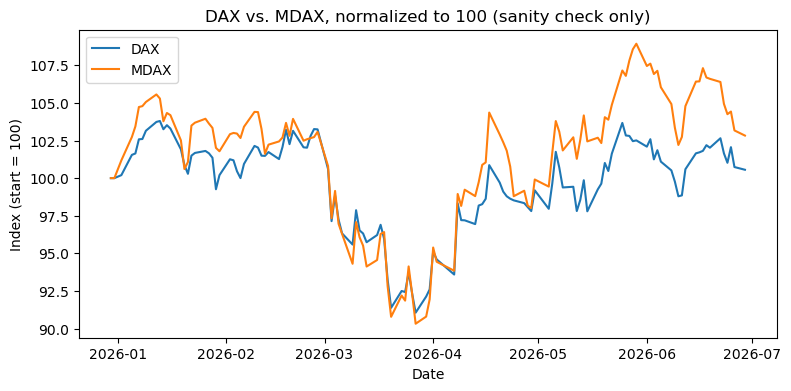

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for ticker, label in INDEX_TICKERS.items():
    sub = prices_long[prices_long["ticker"] == ticker]
    ax.plot(sub["date"], sub["normalized"], label=label)
ax.set_title("DAX vs. MDAX, normalized to 100 (sanity check only)")
ax.set_xlabel("Date")
ax.set_ylabel("Index (start = 100)")
ax.legend()
plt.show()


## 13. Build the Star Schema for Power BI

The four exported tables form a small star schema rather than a set of unrelated CSVs.

| Table | Type | Purpose | Key |
|---|---|---|---|
| `daily_market_data` | Fact | Daily price, return, and volume observations for every ticker, including the two indices | `date` + `ticker` |
| `company_metadata` | Dimension | Ticker, name, index group, and sector for every company | `ticker` |
| `company_summary` | Fact (1:1 with `company_metadata`) | Total return, volatility, drawdown, rank per company | `ticker` |
| `monthly_summary` | Fact | Monthly return and volatility per index | `month` + `index_group` |

`daily_market_data` and `company_summary` both relate to `company_metadata` on `ticker` (many-to-one and one-to-one respectively). A `Dim_Date` calendar table is not exported here — it is faster to generate with `CALENDAR()` directly in Power BI and relate it to `daily_market_data[date]` for time intelligence.

## 14. Export Tables for Power BI

In [14]:
daily_market_data = prices_long.merge(
    company_metadata[["ticker", "index_group"]], on="ticker", how="left"
)
daily_market_data.loc[daily_market_data["ticker"].isin(INDEX_TICKERS), "index_group"] = (
    daily_market_data["ticker"].map(INDEX_TICKERS)
)

daily_market_data.to_csv(PROCESSED_DIR / "daily_market_data.csv", index=False)
company_metadata.to_csv(PROCESSED_DIR / "company_metadata.csv", index=False)
company_summary.to_csv(PROCESSED_DIR / "company_summary.csv", index=False)
monthly_summary.to_csv(PROCESSED_DIR / "monthly_summary.csv", index=False)

print("Exported:", [p.name for p in sorted(PROCESSED_DIR.glob("*.csv"))])


Exported: ['company_metadata.csv', 'company_summary.csv', 'daily_market_data.csv', 'monthly_summary.csv']


## 15. Limitations

The analysis covers a single half-year (H1 2026, roughly 125 trading days). Volatility and drawdown figures describe this specific window and should not be read as a general risk profile of either index.

Index composition is fixed to a single cutoff date (30 June 2026); companies that joined or left DAX or MDAX during the period are treated by their status at that date, not their status throughout H1.

A small number of MDAX small-caps may have thin trading data; gaps of up to two days are forward-filled, longer gaps are dropped (see Section 5 for the exact count). Sector labels follow a single taxonomy applied to both indices, and rank is based on total return, not market capitalization.

Transaction costs, dividends beyond what `yfinance` includes in the adjusted close, and taxes are not modeled.

## 16. Summary and Key Findings

- The MDAX outperformed the DAX over H1 2026: **+2.83%** versus **+0.56%**.
- The MDAX was also the riskier index: annualized volatility **22.10%** versus DAX **18.71%**, and a deeper maximum drawdown of **-14.43%** versus DAX **-12.27%**.
- A slim majority of companies in both indices posted a positive H1 2026 return: **55%** of DAX companies, **56%** of MDAX companies.
- The median company outperformed its own cap-weighted index in both cases — DAX index return sat **2.92 pp** below its median company, MDAX **0.59 pp** below — so the move was broad-based rather than carried only by the largest names. The gap is wider for the DAX; since this notebook does not compute market-cap weights, the exact cause (which large constituents pulled the cap-weighted index down) is not something this data can confirm — it would need each company's index weight, which is out of scope here.
- Strongest performers: **Aixtron** (MDAX, +201.0%) and **Infineon Technologies** (DAX, +109.0%); weakest: **KION Group** (MDAX, -43.8%) and **Rheinmetall** (DAX, -37.2%).
- Strongest and weakest sectors: see the Power BI dashboard's Sector Explorer page (Page 4) for the full sector-level breakdown, split by DAX and MDAX.